# KaChing Walk-Forward Backtester

**Strategy**: Weekly short puts (6-9 DTE) + protective long put (90-150 DTE, delta ~-0.25)  
**Universe**: A-tier tickers from `outputs/kaching_scored_stocks.csv`  
**Method**: Walk-forward with train=180d / test=120d / step=60d windows

---
## Section 1 — Setup

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

from src.postprocess import (
    filter_weekly_put_options,
    OTM_LABELS,
    OTM_BINS,
    MONEYNESS_THRESHOLD,
)

print('Imports OK')
print(f'OTM buckets ({len(OTM_LABELS)}): {OTM_LABELS}')

Imports OK
OTM buckets (10): ['0.0-0.5%', '0.5-1.0%', '1.0-1.5%', '1.5-2.0%', '2.0-2.5%', '2.5-3.0%', '3.0-3.5%', '3.5-4.0%', '4.0-4.5%', '4.5-5.0%']


In [2]:
# ── Walk-forward parameters ──────────────────────────────────────────────
TRAIN_DAYS       = 180   # ~6 months training window
TEST_DAYS        = 120   # 1 protective-put cycle, ~16 weekly trades
STEP_DAYS        = 60    # Advance window by this many days

# ── Universe filter ──────────────────────────────────────────────────────
TIER_FILTER      = 'A'

# ── Long put parameters ──────────────────────────────────────────────────
LONG_DTE_MIN     = 90
LONG_DTE_MAX     = 150
LONG_DELTA_TGT   = -0.25
LONG_DELTA_TOL   = 0.05

# ── Strategy parameters ──────────────────────────────────────────────────
SELECTION_METHOD = 'composite'  # 'ev' | 'winrate' | 'sharpe' | 'composite'
ENTRY_DOW        = None         # None=both Thu+Fri, 3=Thu only, 4=Fri only

# ── Paths ────────────────────────────────────────────────────────────────
PROJECT_ROOT     = Path('..').resolve()
DATA_DIR         = PROJECT_ROOT / 'data' / 'raw' / 'dataset'
SCORES_CSV       = PROJECT_ROOT / 'outputs' / 'kaching_scored_stocks.csv'

print(f'DATA_DIR  : {DATA_DIR}')
print(f'SCORES_CSV: {SCORES_CSV}')

DATA_DIR  : /home/calvin/code/kaching-v2/data/raw/dataset
SCORES_CSV: /home/calvin/code/kaching-v2/outputs/kaching_scored_stocks.csv


In [3]:
scores_df = pd.read_csv(SCORES_CSV)

# Strip $ formatting from monetary string columns only
for col in ['best_bucket_avg_spread', 'latest_price']:
    if col in scores_df.columns and scores_df[col].dtype == object:
        scores_df[col] = scores_df[col].str.replace('$', '', regex=False)
        scores_df[col] = pd.to_numeric(scores_df[col], errors='coerce')

# Filter to target tier
universe_df = scores_df[scores_df['tier'] == TIER_FILTER].copy()
universe = universe_df['ticker'].tolist()

# Only keep tickers that have a parquet file on disk
universe = [t for t in universe if (DATA_DIR / f'{t}.parquet').exists()]

print(f'{TIER_FILTER}-tier tickers with data: {len(universe)}')
print(universe)

A-tier tickers with data: 30
['SNAP', 'MARA', 'BB', 'AI', 'ENVX', 'RIOT', 'NIO', 'OPEN', 'TDOC', 'IONQ', 'MSOS', 'DJT', 'CLSK', 'SOFI', 'GME', 'CLF', 'IREN', 'ETSY', 'DKNG', 'SOUN', 'ASAN', 'RUM', 'OSCR', 'CIFR', 'HTZ', 'ACHR', 'JOBY', 'S', 'BULL', 'CZR']


---
## Section 2 — Helper Functions

In [4]:
def pick_trade(day_df):
    """Return the row with highest bid; None if empty."""
    if day_df.empty:
        return None
    return day_df.loc[day_df['bid'].idxmax()]


def select_bucket_training(train_df, method):
    """
    Select the best OTM bucket to sell based on training data.

    Args:
        train_df: DataFrame with 'otm_bucket', 'pnl', 'win' columns
        method: 'ev' | 'winrate' | 'sharpe' | 'composite'

    Returns:
        Best bucket label string, or None if no bucket has n >= 5
    """
    if train_df.empty:
        return None

    df = train_df.copy()
    # Drop rows with missing bucket (otm_pct outside 0-5% range)
    df = df[df['otm_bucket'].notna()]
    df['bucket_str'] = df['otm_bucket'].astype(str)

    stats = []
    for bucket, grp in df.groupby('bucket_str'):
        n = len(grp)
        if n < 5:
            continue
        ev = grp['pnl'].mean()
        wr = grp['win'].mean()
        std = grp['pnl'].std()
        sharpe = ev / std if (std > 0 and not np.isnan(std)) else 0.0
        stats.append({'bucket': bucket, 'n': n, 'ev': ev, 'winrate': wr, 'sharpe': sharpe})

    if not stats:
        return None

    sdf = pd.DataFrame(stats)

    if method == 'ev':
        best = sdf.loc[sdf['ev'].idxmax(), 'bucket']
    elif method == 'winrate':
        best = sdf.loc[sdf['winrate'].idxmax(), 'bucket']
    elif method == 'sharpe':
        best = sdf.loc[sdf['sharpe'].idxmax(), 'bucket']
    elif method == 'composite':
        def norm_col(s):
            r = s.max() - s.min()
            return (s - s.min()) / r if r > 0 else s * 0.0
        sdf['score'] = (
            0.5 * norm_col(sdf['ev'])
            + 0.3 * sdf['winrate']
            + 0.2 * norm_col(sdf['sharpe'])
        )
        best = sdf.loc[sdf['score'].idxmax(), 'bucket']
    else:
        raise ValueError(f'Unknown method: {method}')

    return best if best in OTM_LABELS else None


def get_trade_for_week(week_df, target_bucket):
    """
    Get best trade for a week, cascading to adjacent buckets if target is empty.
    Tries: target, +1 (deeper OTM), -1 (shallower), +2, -2, ...

    Returns:
        (trade_row, actual_bucket_used) or (None, None)
    """
    if target_bucket is None or target_bucket not in OTM_LABELS:
        return None, None

    wdf = week_df.copy()
    wdf = wdf[wdf['otm_bucket'].notna()]
    wdf['bucket_str'] = wdf['otm_bucket'].astype(str)

    target_idx = OTM_LABELS.index(target_bucket)
    offsets = [0, 1, -1, 2, -2, 3, -3, 4, -4, 5, -5]

    for offset in offsets:
        idx = target_idx + offset
        if 0 <= idx < len(OTM_LABELS):
            bucket = OTM_LABELS[idx]
            bucket_df = wdf[wdf['bucket_str'] == bucket]
            trade = pick_trade(bucket_df)
            if trade is not None:
                return trade, bucket

    return None, None


print('Short put helpers defined.')

Short put helpers defined.


In [5]:
def filter_long_puts(raw_df, dte_min=90, dte_max=150, delta_target=-0.25, delta_tol=0.05):
    """
    Filter raw options to long put candidates.
    - PUT options only
    - Split ratio filter
    - DTE in [dte_min, dte_max]
    - Delta ~delta_target ± delta_tol (widens up to ±0.15 if no match)
    - Fallback to moneyness proxy if no delta column
    - ask > 0
    - One row per (date, strike, expiry) — last quote of day
    """
    df = raw_df[raw_df['right'] == 'PUT'].copy()

    # Split ratio filter
    ratio = df['underlying_price'] / df['underlying_close']
    df = df[(ratio > 0.9) & (ratio < 1.1)]

    # DTE filter
    df['dte'] = (pd.to_datetime(df['expiration']) - pd.to_datetime(df['timestamp'])).dt.days
    df = df[(df['dte'] >= dte_min) & (df['dte'] <= dte_max)]

    if df.empty:
        return pd.DataFrame()

    # Delta / moneyness filter
    if 'delta' in df.columns:
        matched = False
        for extra_tol in [0.0, 0.05, 0.10]:
            tol = delta_tol + extra_tol
            delta_df = df[
                (df['delta'] >= delta_target - tol) &
                (df['delta'] <= delta_target + tol)
            ]
            if not delta_df.empty:
                df = delta_df
                matched = True
                break
        if not matched:
            return pd.DataFrame()
    else:
        # Moneyness proxy: delta ~-0.25 corresponds roughly to 3-10% OTM put
        moneyness = (df['strike'] - df['underlying_price']) / df['underlying_price']
        df = df[(moneyness >= 0.03) & (moneyness <= 0.10)]

    # Ask > 0
    df = df[df['ask'] > 0]

    if df.empty:
        return pd.DataFrame()

    # One row per (date, strike, expiry) — last quote of day
    df['quote_date'] = pd.to_datetime(df['timestamp']).dt.date
    df = df.sort_values('timestamp')
    df = df.groupby(['quote_date', 'strike', 'expiration']).last().reset_index()

    return df


def price_long_put_at_expiry(long_put_row, raw_df):
    """
    Look up the underlying close on the expiration date.
    Returns max(0, strike - close) or NaN if the date is missing.
    """
    expiry = pd.to_datetime(long_put_row['expiration']).date()
    strike = long_put_row['strike']

    dates = pd.to_datetime(raw_df['underlying_date']).dt.date
    price_rows = raw_df[dates == expiry]

    if price_rows.empty:
        return np.nan

    close_price = float(price_rows['underlying_close'].iloc[-1])
    return float(max(0.0, strike - close_price))


print('Long put helpers defined.')

Long put helpers defined.


---
## Section 3 — Walk-Forward Engine

In [6]:
def run_walkforward_single(ticker, entry_dow=None, selection_method='composite'):
    """
    Run walk-forward backtest for a single ticker.

    Args:
        ticker: Ticker symbol string
        entry_dow: None=Thu+Fri, 3=Thu only, 4=Fri only
        selection_method: 'ev' | 'winrate' | 'sharpe' | 'composite'

    Returns:
        dict with keys 'ticker', 'trades', 'long_puts', 'windows'
    """
    raw_df = pd.read_parquet(DATA_DIR / f'{ticker}.parquet')

    # --- Short puts: filter_weekly_put_options handles Thu/Fri + DTE 6-9 ---
    short_puts_df, _ = filter_weekly_put_options(raw_df)

    # Optional additional DOW filter
    if entry_dow is not None:
        dow = pd.to_datetime(short_puts_df['quote_date'].astype(str)).dt.dayofweek
        short_puts_df = short_puts_df[dow == entry_dow]

    # --- Long put candidates ---
    long_puts_df = filter_long_puts(
        raw_df, LONG_DTE_MIN, LONG_DTE_MAX, LONG_DELTA_TGT, LONG_DELTA_TOL
    )

    empty = {'ticker': ticker, 'trades': pd.DataFrame(),
             'long_puts': pd.DataFrame(), 'windows': pd.DataFrame()}
    if short_puts_df.empty:
        return empty

    # Parse quote_date to Timestamp for window arithmetic
    sp = short_puts_df.copy()
    sp['quote_ts'] = pd.to_datetime(sp['quote_date'].astype(str))
    min_date = sp['quote_ts'].min()
    max_date = sp['quote_ts'].max()

    all_trades  = []
    all_long    = []
    all_windows = []

    window_start = min_date
    while True:
        train_end  = window_start + pd.Timedelta(days=TRAIN_DAYS)
        test_start = train_end
        test_end   = test_start + pd.Timedelta(days=TEST_DAYS)

        if test_end > max_date:
            break

        # ── Training: select best bucket per method ───────────────────────
        train_mask = (sp['quote_ts'] >= window_start) & (sp['quote_ts'] < train_end)
        train_df = sp[train_mask]

        best_by_method = {}
        for m in ['ev', 'winrate', 'sharpe', 'composite']:
            best_by_method[m] = select_bucket_training(train_df, m)

        target_bucket = best_by_method[selection_method]

        # ── Test: simulate weekly trades ──────────────────────────────────
        test_mask = (sp['quote_ts'] >= test_start) & (sp['quote_ts'] < test_end)
        test_df = sp[test_mask].copy()
        test_df['week'] = test_df['quote_ts'].dt.to_period('W')

        window_trades = []
        fallback_count = 0

        for _week, week_df in test_df.groupby('week'):
            trade_row, bucket_used = get_trade_for_week(week_df, target_bucket)
            if trade_row is None:
                continue
            trade = trade_row.to_dict()
            trade['ticker']           = ticker
            trade['window_start']     = test_start
            trade['bucket_selected']  = target_bucket
            trade['bucket_used']      = bucket_used
            trade['fallback_used']    = (bucket_used != target_bucket)
            if trade['fallback_used']:
                fallback_count += 1
            window_trades.append(trade)

        # ── Long put: one per test window ─────────────────────────────────
        long_record = None
        if not long_puts_df.empty:
            lp_dates = pd.to_datetime(long_puts_df['quote_date'].astype(str))
            lp_mask  = (lp_dates >= test_start) & (lp_dates < test_end)
            window_lp = long_puts_df[lp_mask]
            if not window_lp.empty:
                lp_row        = window_lp.iloc[0]
                terminal_val  = price_long_put_at_expiry(lp_row, raw_df)
                long_pnl      = (terminal_val - float(lp_row['ask'])) if not np.isnan(terminal_val) else np.nan
                long_record   = {
                    'ticker':         ticker,
                    'window_start':   test_start,
                    'quote_date':     lp_row['quote_date'],
                    'strike':         lp_row['strike'],
                    'expiration':     lp_row['expiration'],
                    'ask_paid':       float(lp_row['ask']),
                    'terminal_value': terminal_val,
                    'long_pnl':       long_pnl,
                }

        # ── Window summary ────────────────────────────────────────────────
        n_t         = len(window_trades)
        short_pnl   = sum(t.get('pnl', 0) for t in window_trades)
        long_pnl_v  = long_record['long_pnl'] if long_record is not None else np.nan
        total_pnl   = short_pnl + (long_pnl_v if not pd.isna(long_pnl_v) else 0.0)

        all_windows.append({
            'ticker':         ticker,
            'window_start':   test_start,
            'window_end':     test_end,
            'target_bucket':  target_bucket,
            **{f'best_{m}': best_by_method[m] for m in ['ev', 'winrate', 'sharpe', 'composite']},
            'n_trades':       n_t,
            'short_pnl':      short_pnl,
            'long_pnl':       long_pnl_v,
            'total_pnl':      total_pnl,
            'fallback_count': fallback_count,
        })

        all_trades.extend(window_trades)
        if long_record is not None:
            all_long.append(long_record)

        window_start += pd.Timedelta(days=STEP_DAYS)

    return {
        'ticker':    ticker,
        'trades':    pd.DataFrame(all_trades)  if all_trades  else pd.DataFrame(),
        'long_puts': pd.DataFrame(all_long)    if all_long    else pd.DataFrame(),
        'windows':   pd.DataFrame(all_windows) if all_windows else pd.DataFrame(),
    }


print('run_walkforward_single defined.')

run_walkforward_single defined.


In [7]:
results = {}
errors  = {}

for ticker in tqdm(universe, desc='Walk-forward backtest'):
    try:
        results[ticker] = run_walkforward_single(
            ticker,
            entry_dow=ENTRY_DOW,
            selection_method=SELECTION_METHOD,
        )
    except Exception as e:
        errors[ticker] = str(e)
        print(f'  x {ticker}: {e}')

print(f'\nCompleted: {len(results)} tickers | Errors: {len(errors)}')
if errors:
    print(f'Failed: {list(errors.keys())}')

Walk-forward backtest:   0%|          | 0/30 [00:00<?, ?it/s]


Completed: 30 tickers | Errors: 0


In [8]:
# Concatenate across tickers
trades_parts  = [r['trades']    for r in results.values() if not r['trades'].empty]
lp_parts      = [r['long_puts'] for r in results.values() if not r['long_puts'].empty]
windows_parts = [r['windows']   for r in results.values() if not r['windows'].empty]

all_trades_df  = pd.concat(trades_parts,  ignore_index=True) if trades_parts  else pd.DataFrame()
all_long_df    = pd.concat(lp_parts,      ignore_index=True) if lp_parts      else pd.DataFrame()
all_windows_df = pd.concat(windows_parts, ignore_index=True) if windows_parts else pd.DataFrame()

# Deduplicate trades — walk-forward windows overlap so same trade may appear twice
if not all_trades_df.empty:
    dedup_cols = [c for c in ['ticker', 'quote_date', 'strike', 'expiration']
                  if c in all_trades_df.columns]
    before = len(all_trades_df)
    all_trades_df = all_trades_df.drop_duplicates(subset=dedup_cols)
    print(f'Trades: {before} -> {len(all_trades_df)} after dedup ({before - len(all_trades_df)} removed)')

print(f'Total trades:    {len(all_trades_df)}')
print(f'Total long puts: {len(all_long_df)}')
print(f'Total windows:   {len(all_windows_df)}')

if not all_trades_df.empty and 'quote_date' in all_trades_df.columns:
    print(f"Date range: {all_trades_df['quote_date'].min()} -> {all_trades_df['quote_date'].max()}")
    print(f"Tickers in trades: {all_trades_df['ticker'].nunique()}")

Trades: 7526 -> 5493 after dedup (2033 removed)
Total trades:    5493
Total long puts: 687
Total windows:   687
Date range: 2021-07-08 -> 2026-02-12
Tickers in trades: 29


---
## Section 4 — Metrics

In [9]:
def compute_sharpe(pnl_series):
    """Annualized Sharpe (weekly trades x sqrt(52))."""
    s = pnl_series.dropna()
    if len(s) < 2:
        return np.nan
    std = s.std()
    if std == 0 or np.isnan(std):
        return np.nan
    return float((s.mean() / std) * np.sqrt(52))


def compute_max_drawdown(cumulative):
    """Peak-to-trough max drawdown."""
    if len(cumulative) == 0:
        return np.nan
    peak = cumulative.cummax()
    return float((cumulative - peak).min())


# ── Per-ticker metrics ────────────────────────────────────────────────────
ticker_metrics = []

for ticker, res in results.items():
    trades   = res['trades']
    lp       = res['long_puts']
    windows  = res['windows']

    if trades.empty or 'pnl' not in trades.columns:
        continue

    pnl          = trades['pnl'].dropna()
    n_trades     = len(pnl)
    total_short  = float(pnl.sum())
    win_rate     = float((pnl > 0).mean())
    avg_premium  = float(trades['bid'].mean()) if 'bid' in trades.columns else np.nan
    sharpe       = compute_sharpe(pnl)
    max_dd       = compute_max_drawdown(pnl.cumsum().reset_index(drop=True))

    total_long   = float(lp['long_pnl'].sum()) if (not lp.empty and 'long_pnl' in lp.columns) else 0.0
    net_pnl      = total_short + total_long

    fallback_rate = np.nan
    if not windows.empty and 'n_trades' in windows.columns and 'fallback_count' in windows.columns:
        total_t = windows['n_trades'].sum()
        total_f = windows['fallback_count'].sum()
        fallback_rate = float(total_f / total_t) if total_t > 0 else 0.0

    ticker_metrics.append({
        'ticker':            ticker,
        'n_trades':          n_trades,
        'total_short_pnl':   total_short,
        'total_long_pnl':    total_long,
        'net_pnl':           net_pnl,
        'win_rate':          win_rate,
        'avg_weekly_premium': avg_premium,
        'sharpe':            sharpe,
        'max_drawdown':      max_dd,
        'fallback_rate':     fallback_rate,
    })

metrics_df = pd.DataFrame(ticker_metrics).sort_values('sharpe', ascending=False).reset_index(drop=True)
print(f'Metrics computed for {len(metrics_df)} tickers')
metrics_df.head(15)

Metrics computed for 29 tickers


,ticker,n_trades,total_short_pnl,total_long_pnl,net_pnl,win_rate,avg_weekly_premium,sharpe,max_drawdown,fallback_rate
0,JOBY,141,19.68,-14.28,5.40,0.765957,0.288369,3.082460,-1.32,0.829787
1,GME,289,70.50,-30.15,40.35,0.771626,0.683379,1.796854,-9.50,0.631399
2,IREN,149,31.49,-22.06,9.43,0.778523,0.784631,0.875322,-18.33,0.771812
3,IONQ,218,40.87,-24.97,15.90,0.752294,1.081651,0.651700,-24.85,0.623853
4,SOFI,345,15.61,-6.47,9.14,0.715942,0.302522,0.639001,-9.45,0.747826
5,SOUN,81,3.72,-12.42,-8.70,0.728395,0.494444,0.429909,-3.53,0.790123
6,DJT,121,7.73,-1.49,6.24,0.710744,0.750413,0.348030,-15.16,0.677686
7,OSCR,49,1.87,-4.34,-2.47,0.673469,0.623200,0.324100,-5.61,0.740000
8,ASAN,298,3.77,71.86,75.63,0.758389,0.348993,0.104093,-12.54,0.734899
9,CZR,465,8.40,29.44,37.84,0.759140,0.770946,0.085990,-28.52,0.440860


In [10]:
# ── Thu vs Fri entry comparison (first 5 tickers) ─────────────────────────
dow_tickers = universe[:5]
dow_results = {}

for dow, label in [(3, 'Thu'), (4, 'Fri')]:
    dow_results[label] = {}
    for ticker in tqdm(dow_tickers, desc=f'DOW={label}', leave=False):
        try:
            dow_results[label][ticker] = run_walkforward_single(
                ticker, entry_dow=dow, selection_method=SELECTION_METHOD
            )
        except Exception as e:
            print(f'  x {ticker} ({label}): {e}')

# Build comparison table
comparison_rows = []
for label in ['Thu', 'Fri']:
    for ticker, res in dow_results[label].items():
        if res['trades'].empty or 'pnl' not in res['trades'].columns:
            continue
        pnl = res['trades']['pnl'].dropna()
        comparison_rows.append({
            'ticker':    ticker,
            'entry_day': label,
            'n_trades':  len(pnl),
            'total_pnl': round(float(pnl.sum()), 2),
            'win_rate':  round(float((pnl > 0).mean()), 3),
            'sharpe':    round(compute_sharpe(pnl), 3) if len(pnl) >= 2 else np.nan,
        })

comparison_df = pd.DataFrame(comparison_rows)

if not comparison_df.empty:
    pivot = comparison_df.pivot_table(
        index='ticker', columns='entry_day',
        values=['total_pnl', 'win_rate', 'sharpe']
    ).round(3)
    display(pivot)
else:
    print('No Thu/Fri comparison data available.')

DOW=Thu:   0%|          | 0/5 [00:00<?, ?it/s]

DOW=Fri:   0%|          | 0/5 [00:00<?, ?it/s]

sharpe        total_pnl        win_rate       
entry_day    Fri    Thu       Fri    Thu      Fri    Thu
ticker                                                  
AI        -0.002  0.112     -0.07   4.96    0.688  0.687
BB         1.483  2.505      2.69   5.37    0.692  0.696
ENVX      -0.569 -0.235     -8.49  -4.29    0.629  0.642
MARA      -0.398 -0.611    -31.42 -49.20    0.623  0.595
SNAP      -0.752 -0.735    -60.41 -59.21    0.691  0.692

---
## Section 5 — Visualizations

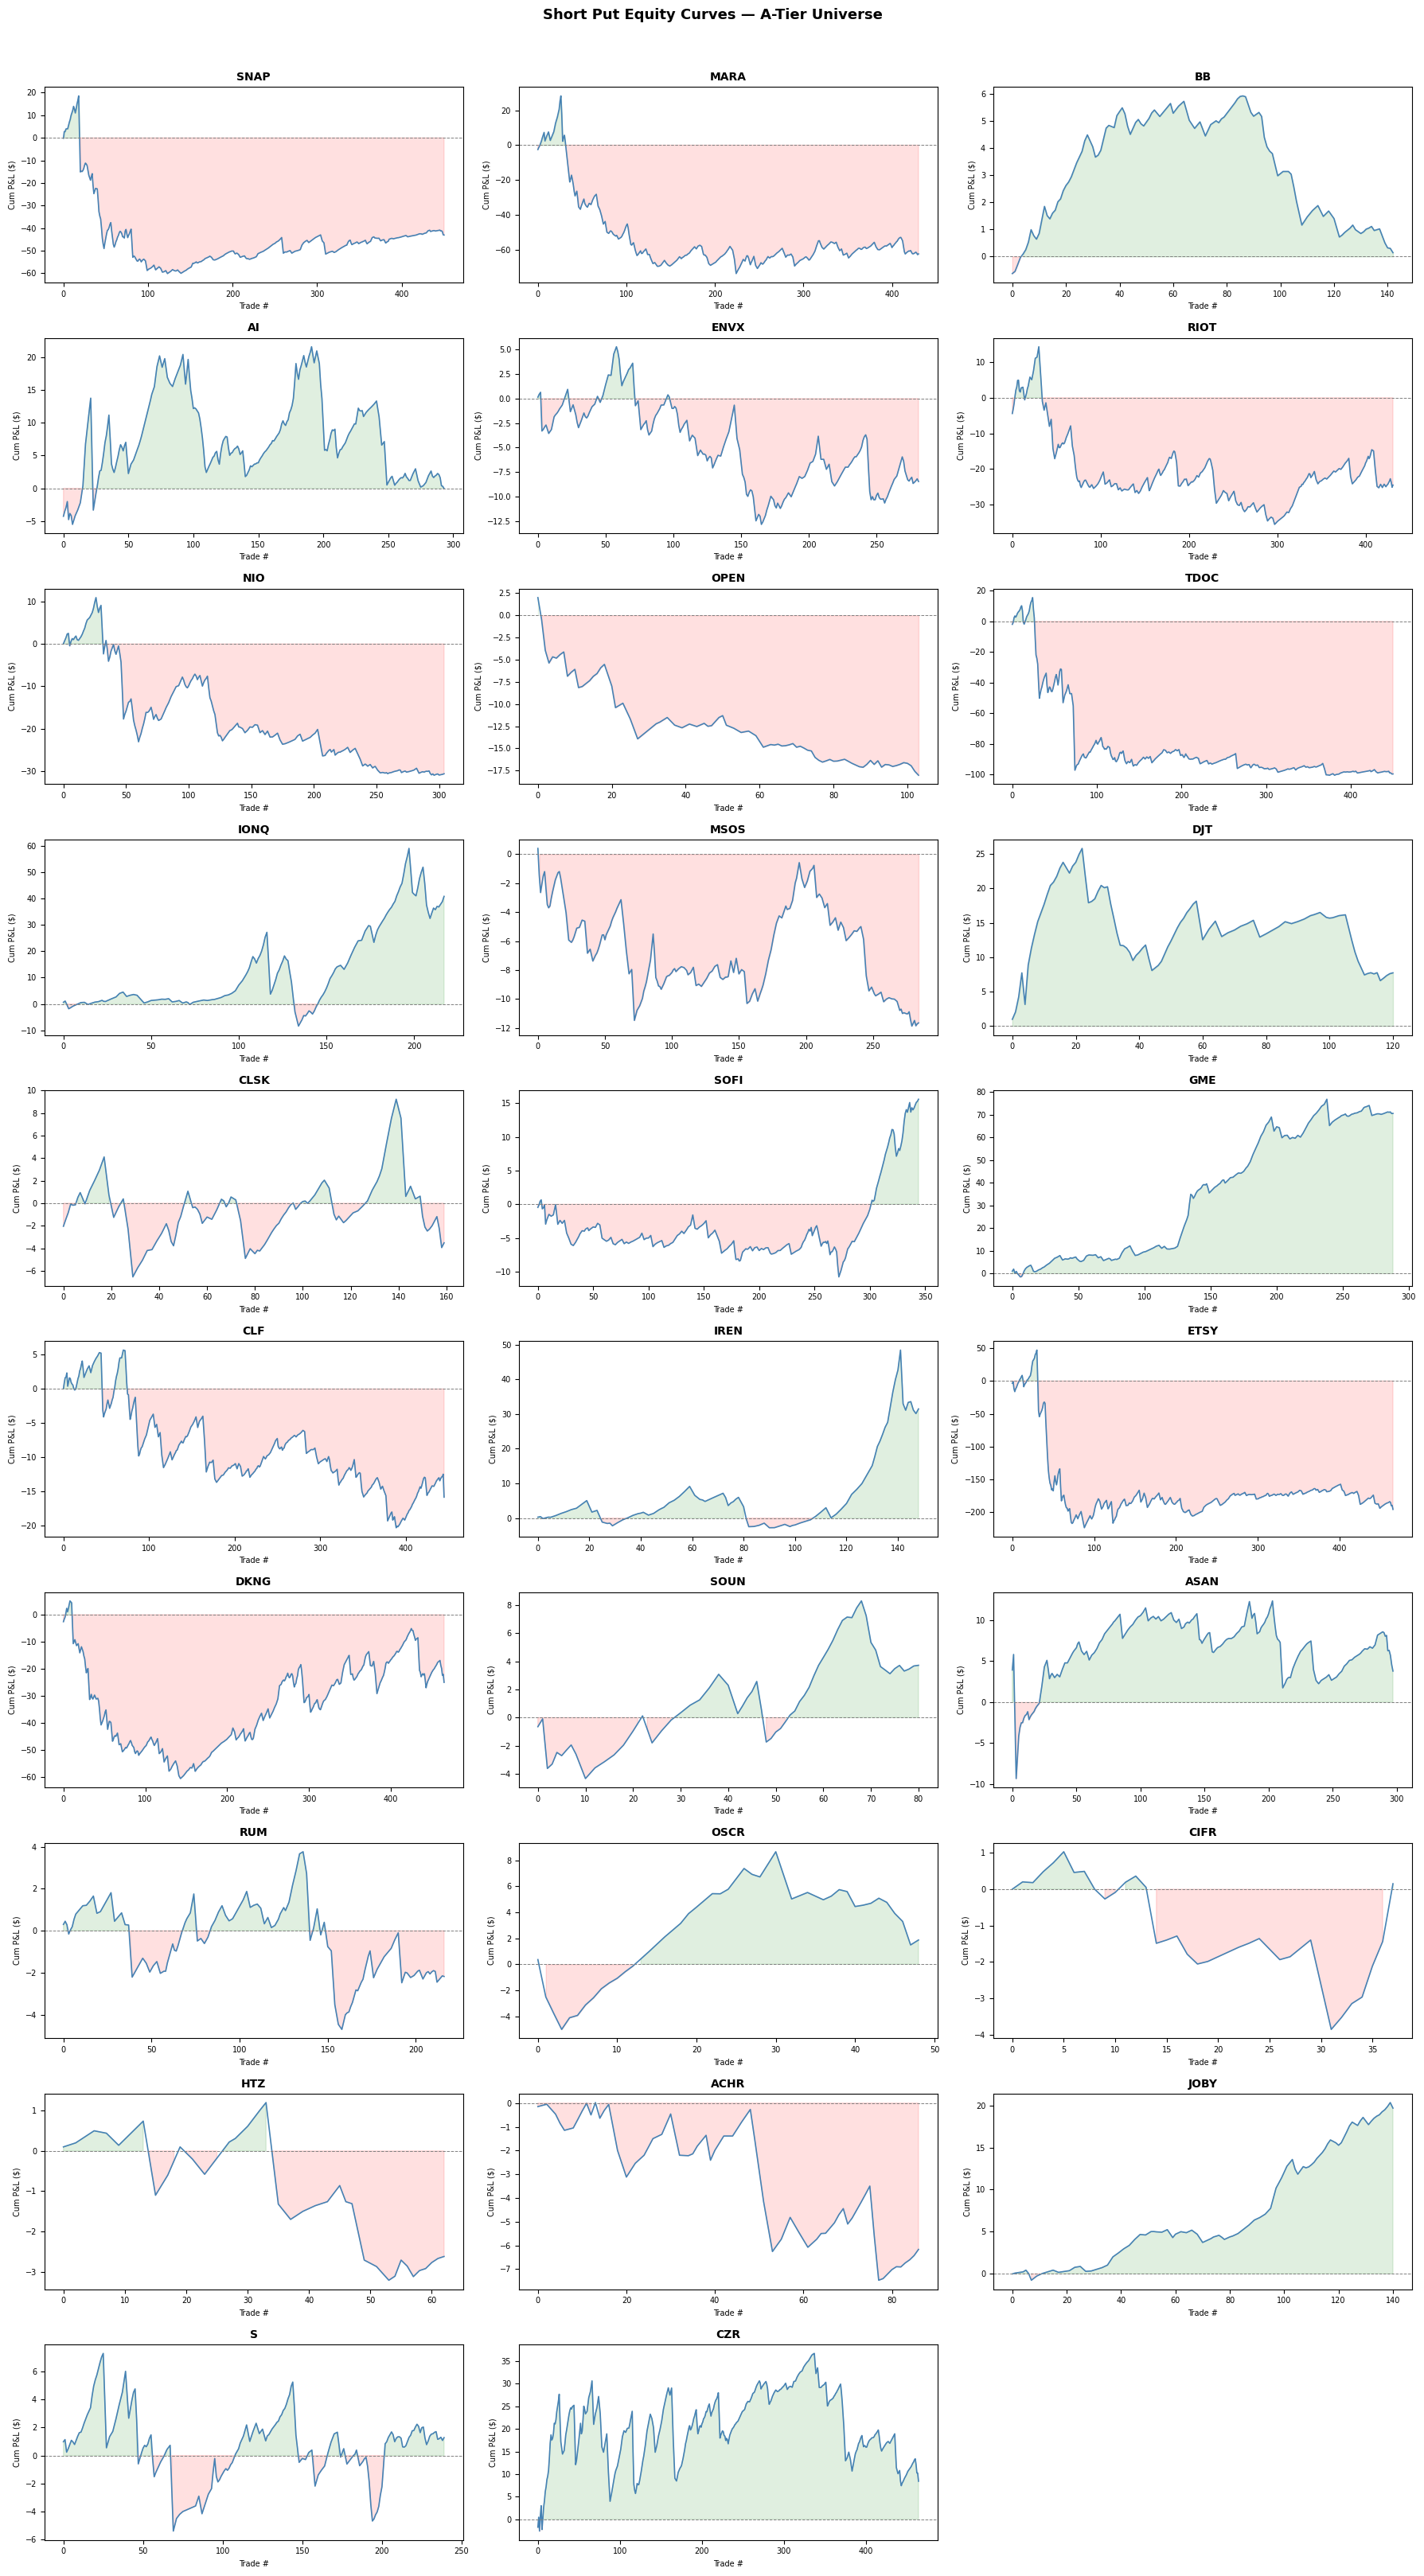

In [11]:
# ── Equity curves grid ────────────────────────────────────────────────────
tickers_with_trades = [
    t for t in universe
    if t in results and not results[t]['trades'].empty
    and 'pnl' in results[t]['trades'].columns
]

ncols = 3
nrows = max(1, (len(tickers_with_trades) + ncols - 1) // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.2))
axes_flat = axes.flatten() if nrows > 1 else list(axes) if ncols == 1 else axes.flatten()

for i, ticker in enumerate(tickers_with_trades):
    ax = axes_flat[i]
    trades = results[ticker]['trades'].sort_values('quote_date')
    pnl = trades['pnl'].dropna()
    cum = pnl.cumsum().reset_index(drop=True)
    x = np.arange(len(cum))

    ax.plot(cum.values, color='steelblue', linewidth=1.2)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.7)
    ax.fill_between(x, cum.values, 0, where=(cum.values >= 0), alpha=0.12, color='green')
    ax.fill_between(x, cum.values, 0, where=(cum.values < 0),  alpha=0.12, color='red')
    ax.set_title(ticker, fontsize=10, fontweight='bold')
    ax.set_xlabel('Trade #', fontsize=7)
    ax.set_ylabel('Cum P&L ($)', fontsize=7)
    ax.tick_params(labelsize=7)

for j in range(len(tickers_with_trades), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Short Put Equity Curves — A-Tier Universe', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

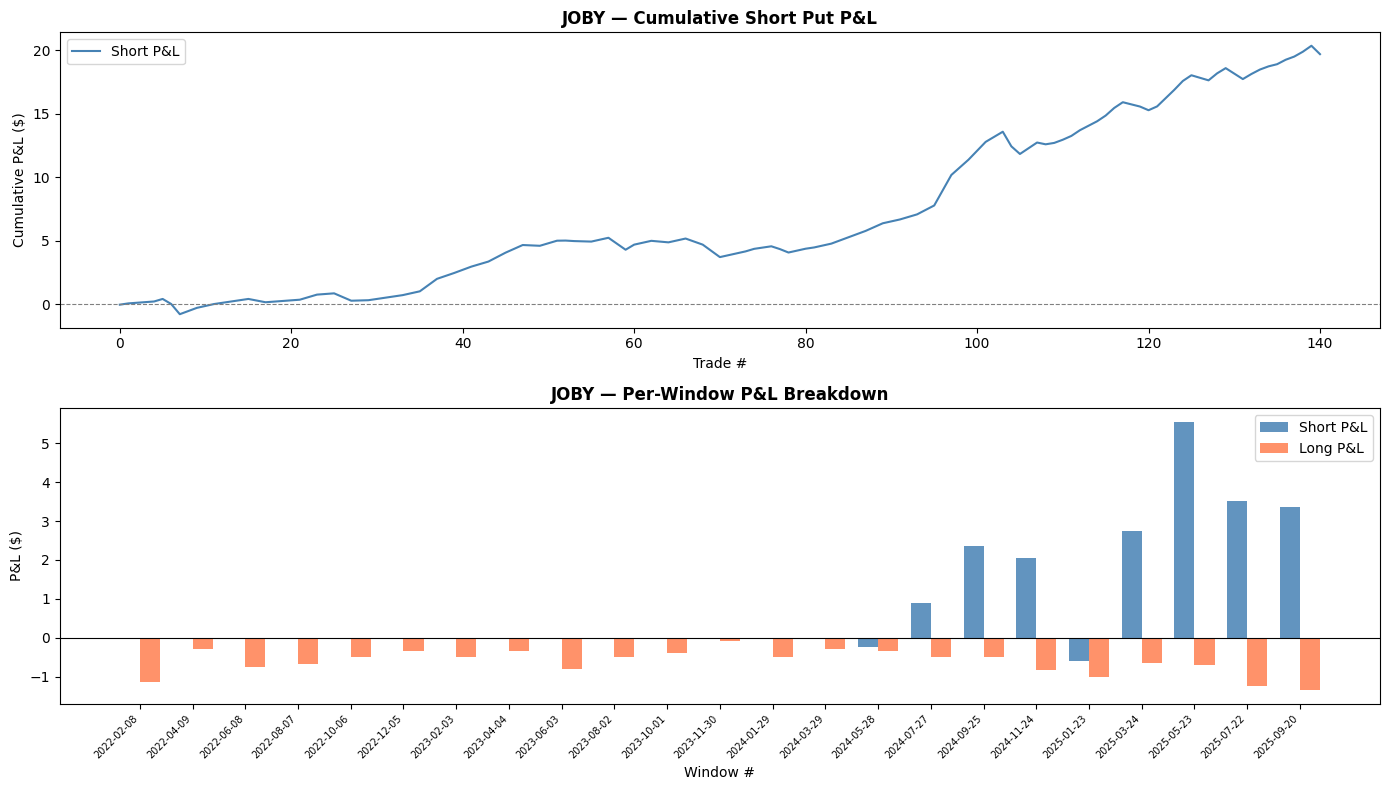

In [12]:
# ── Short vs long breakdown — best-Sharpe ticker ──────────────────────────
if metrics_df.empty:
    print('No metrics available.')
else:
    best_ticker   = metrics_df.iloc[0]['ticker']
    res           = results[best_ticker]
    trades_sorted = res['trades'].sort_values('quote_date') if not res['trades'].empty else pd.DataFrame()
    wins_sorted   = res['windows'].sort_values('window_start') if not res['windows'].empty else pd.DataFrame()

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

    # Top: cumulative equity curve
    if not trades_sorted.empty and 'pnl' in trades_sorted.columns:
        pnl = trades_sorted['pnl'].dropna()
        cum = pnl.cumsum().reset_index(drop=True)
        ax1.plot(cum.values, color='steelblue', linewidth=1.5, label='Short P&L')
        ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8)
        ax1.set_title(f'{best_ticker} — Cumulative Short Put P&L', fontsize=12, fontweight='bold')
        ax1.set_xlabel('Trade #')
        ax1.set_ylabel('Cumulative P&L ($)')
        ax1.legend()

    # Bottom: per-window bar chart (short vs long)
    if not wins_sorted.empty and 'short_pnl' in wins_sorted.columns:
        x     = np.arange(len(wins_sorted))
        width = 0.38
        ax2.bar(x - width / 2, wins_sorted['short_pnl'].fillna(0), width,
                label='Short P&L', color='steelblue', alpha=0.85)
        if 'long_pnl' in wins_sorted.columns:
            ax2.bar(x + width / 2, wins_sorted['long_pnl'].fillna(0), width,
                    label='Long P&L',  color='coral', alpha=0.85)
        ax2.axhline(0, color='black', linewidth=0.8)
        ax2.set_title(f'{best_ticker} — Per-Window P&L Breakdown', fontsize=12, fontweight='bold')
        ax2.set_xlabel('Window #')
        ax2.set_ylabel('P&L ($)')
        ax2.legend()
        ax2.set_xticks(x)
        labels_x = [str(w)[:10] for w in wins_sorted['window_start']]
        ax2.set_xticklabels(labels_x, rotation=45, ha='right', fontsize=7)

    plt.tight_layout()
    plt.show()

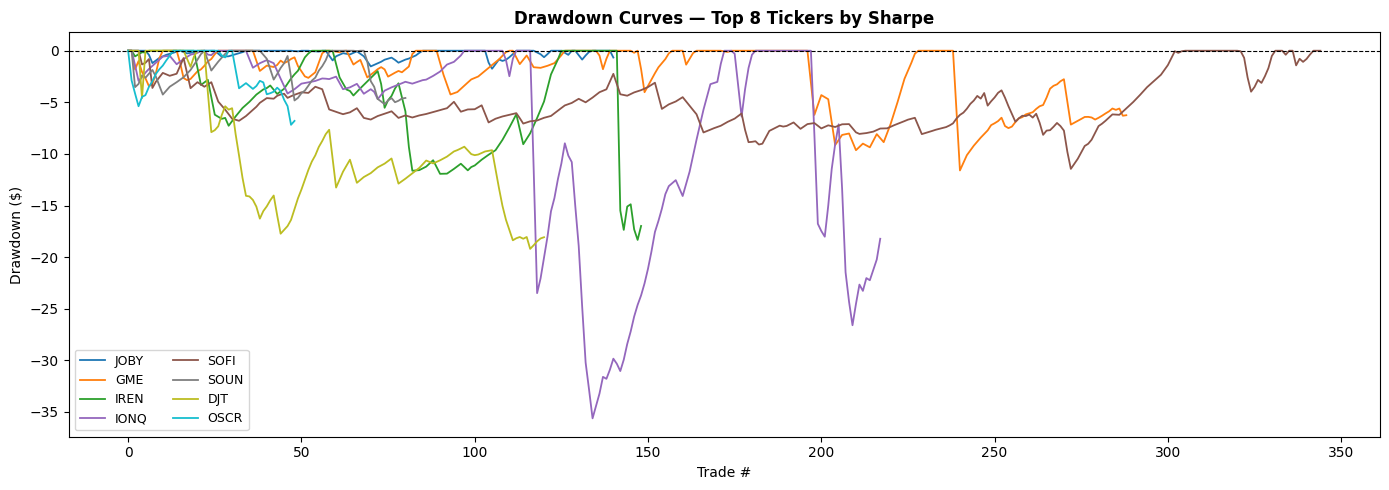

In [13]:
# ── Drawdown curves — top 8 tickers by Sharpe ─────────────────────────────
top8 = metrics_df.dropna(subset=['sharpe']).head(8)['ticker'].tolist()

fig, ax = plt.subplots(figsize=(14, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(top8)))

for ticker, color in zip(top8, colors):
    trades = results[ticker]['trades']
    if trades.empty or 'pnl' not in trades.columns:
        continue
    pnl = trades.sort_values('quote_date')['pnl'].dropna()
    if len(pnl) < 2:
        continue
    cum      = pnl.cumsum().reset_index(drop=True)
    peak     = cum.cummax()
    drawdown = cum - peak
    ax.plot(drawdown.values, label=ticker, color=color, linewidth=1.3)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Drawdown Curves — Top 8 Tickers by Sharpe', fontsize=12, fontweight='bold')
ax.set_xlabel('Trade #')
ax.set_ylabel('Drawdown ($)')
ax.legend(loc='lower left', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

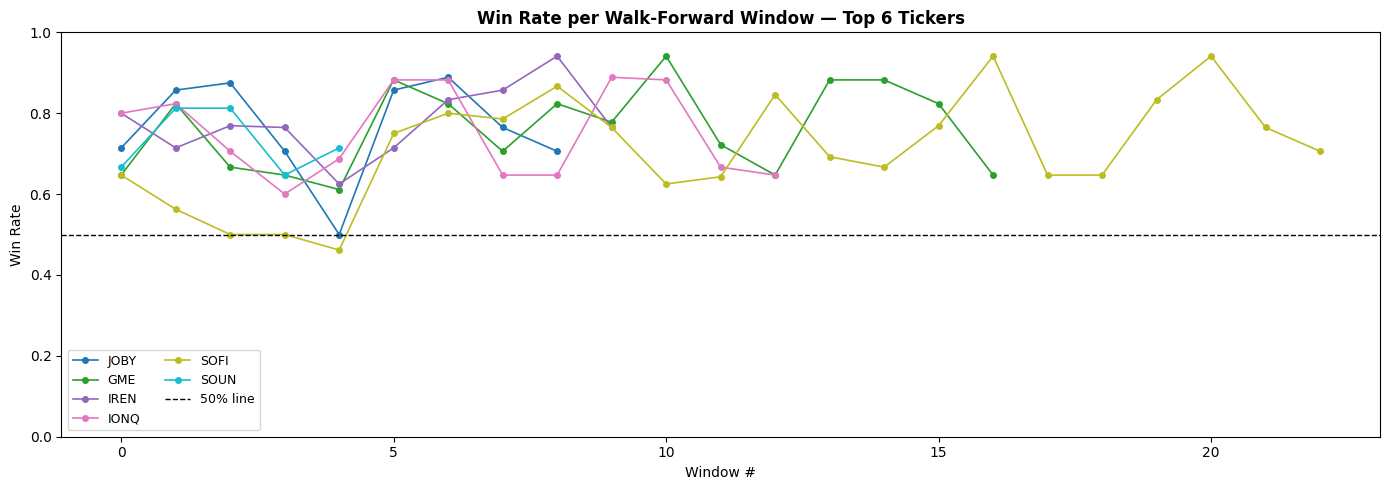

In [14]:
# ── Win rate over windows — top 6 tickers ─────────────────────────────────
top6 = metrics_df.dropna(subset=['sharpe']).head(6)['ticker'].tolist()

fig, ax = plt.subplots(figsize=(14, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(top6)))

for ticker, color in zip(top6, colors):
    res     = results[ticker]
    windows = res['windows']
    trades  = res['trades']
    if windows.empty or trades.empty or 'pnl' not in trades.columns:
        continue

    trades_cp = trades.copy()
    trades_cp['window_start'] = pd.to_datetime(trades_cp['window_start'])

    win_rates = []
    for _, win_row in windows.iterrows():
        ws = pd.to_datetime(win_row['window_start'])
        w_trades = trades_cp[trades_cp['window_start'] == ws]
        if len(w_trades) > 0:
            win_rates.append(float((w_trades['pnl'] > 0).mean()))
        else:
            win_rates.append(np.nan)

    wr_series = pd.Series(win_rates).dropna()
    if not wr_series.empty:
        ax.plot(wr_series.values, label=ticker, color=color,
                linewidth=1.2, marker='o', markersize=4)

ax.axhline(0.5, color='black', linestyle='--', linewidth=1.0, label='50% line')
ax.set_ylim(0, 1)
ax.set_title('Win Rate per Walk-Forward Window — Top 6 Tickers', fontsize=12, fontweight='bold')
ax.set_xlabel('Window #')
ax.set_ylabel('Win Rate')
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

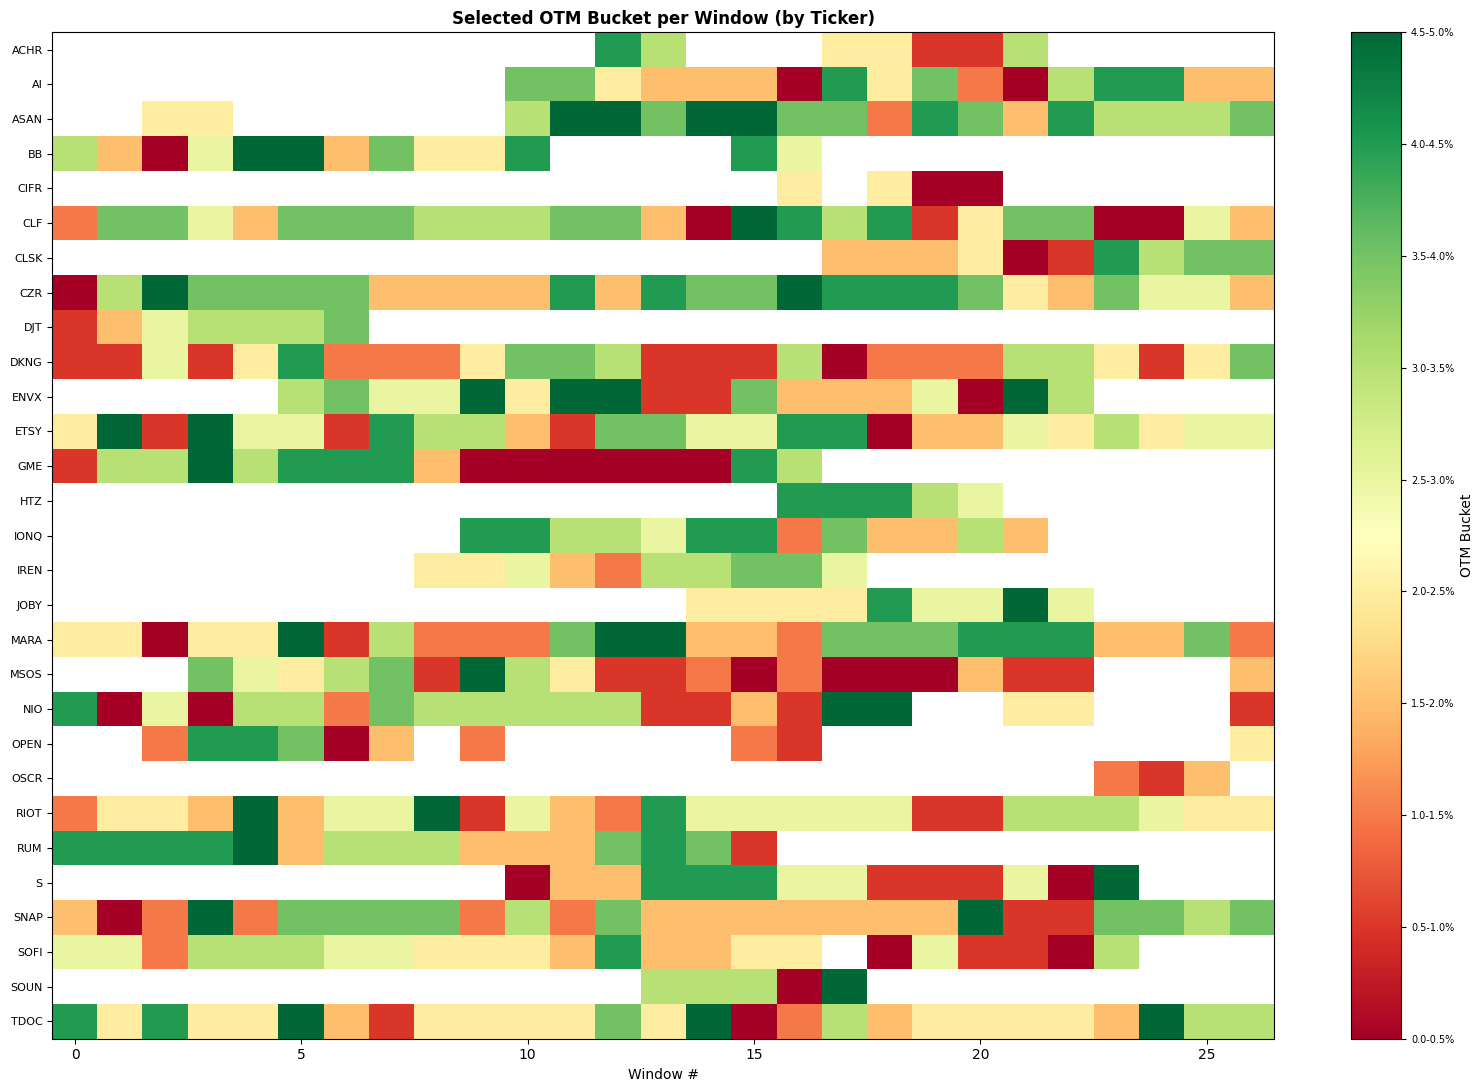

In [15]:
# ── Bucket stability heatmap ───────────────────────────────────────────────
if not all_windows_df.empty and 'target_bucket' in all_windows_df.columns:
    wdf = all_windows_df.copy()
    wdf['window_idx']  = wdf.groupby('ticker').cumcount()
    label_to_idx       = {lbl: i for i, lbl in enumerate(OTM_LABELS)}
    wdf['bucket_idx']  = wdf['target_bucket'].map(label_to_idx)

    pivot = wdf.pivot_table(
        index='ticker', columns='window_idx',
        values='bucket_idx', aggfunc='first'
    )

    h = max(6, len(pivot) * 0.38)
    fig, ax = plt.subplots(figsize=(16, h))
    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn',
                   vmin=0, vmax=len(OTM_LABELS) - 1)

    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=8)
    ax.set_xlabel('Window #')
    ax.set_title('Selected OTM Bucket per Window (by Ticker)', fontsize=12, fontweight='bold')

    cbar = plt.colorbar(im, ax=ax, ticks=range(len(OTM_LABELS)))
    cbar.ax.set_yticklabels(OTM_LABELS, fontsize=7)
    cbar.set_label('OTM Bucket')

    plt.tight_layout()
    plt.show()
else:
    print('No window data for heatmap.')

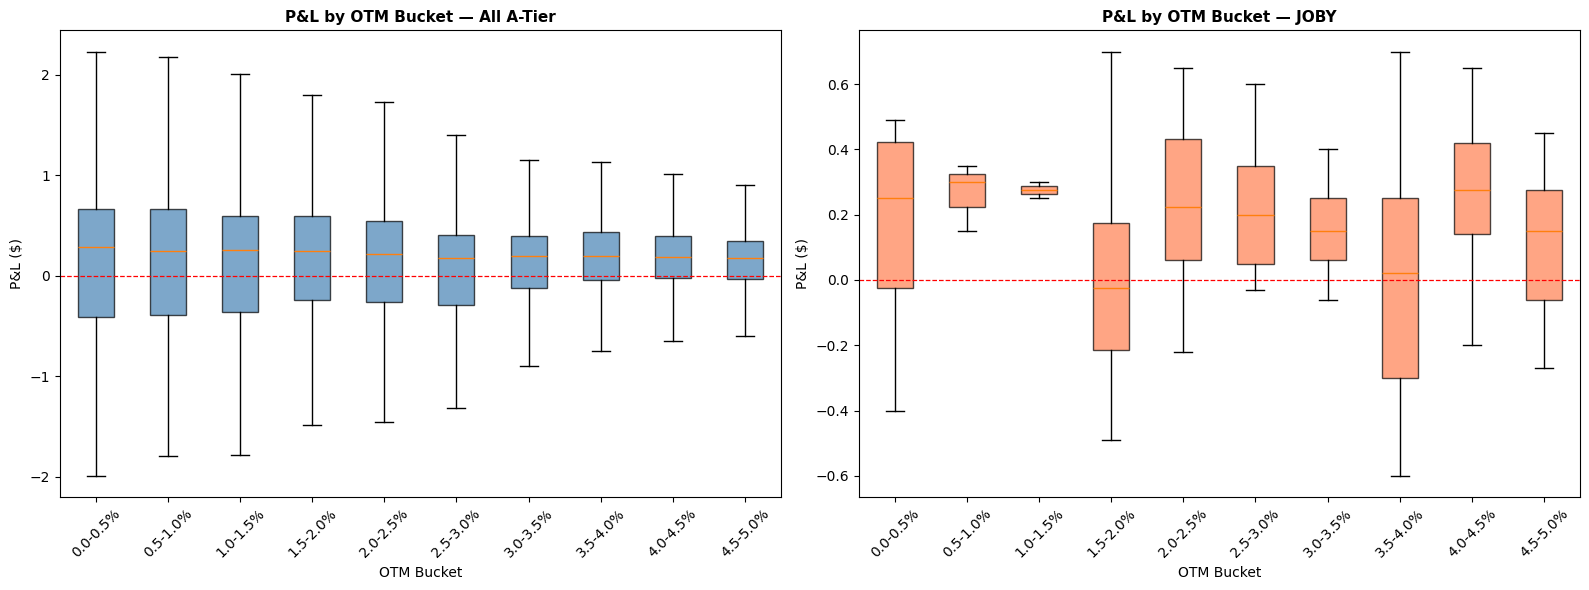

In [16]:
# ── P&L box plots by OTM bucket ───────────────────────────────────────────
if all_trades_df.empty or 'otm_bucket' not in all_trades_df.columns:
    print('No trade data for box plots.')
else:
    atdf = all_trades_df.copy()
    atdf['bucket_str'] = atdf['otm_bucket'].astype(str)

    best_sharpe_ticker = metrics_df.iloc[0]['ticker'] if not metrics_df.empty else None

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # All tickers combined
    present_buckets = [b for b in OTM_LABELS if b in atdf['bucket_str'].values]
    data_all = [atdf[atdf['bucket_str'] == b]['pnl'].dropna().values for b in present_buckets]
    ax1.boxplot(data_all, labels=present_buckets, showfliers=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
    ax1.axhline(0, color='red', linestyle='--', linewidth=0.9)
    ax1.set_title('P&L by OTM Bucket — All A-Tier', fontsize=11, fontweight='bold')
    ax1.set_xlabel('OTM Bucket')
    ax1.set_ylabel('P&L ($)')
    ax1.tick_params(axis='x', rotation=45)

    # Best Sharpe ticker
    if best_sharpe_ticker and best_sharpe_ticker in atdf['ticker'].values:
        best_df = atdf[atdf['ticker'] == best_sharpe_ticker]
        present2 = [b for b in OTM_LABELS if b in best_df['bucket_str'].values]
        data2    = [best_df[best_df['bucket_str'] == b]['pnl'].dropna().values for b in present2]
        ax2.boxplot(data2, labels=present2, showfliers=False, patch_artist=True,
                    boxprops=dict(facecolor='coral', alpha=0.7))
        ax2.axhline(0, color='red', linestyle='--', linewidth=0.9)
        ax2.set_title(f'P&L by OTM Bucket — {best_sharpe_ticker}', fontsize=11, fontweight='bold')
        ax2.set_xlabel('OTM Bucket')
        ax2.set_ylabel('P&L ($)')
        ax2.tick_params(axis='x', rotation=45)
    else:
        ax2.set_visible(False)

    plt.tight_layout()
    plt.show()

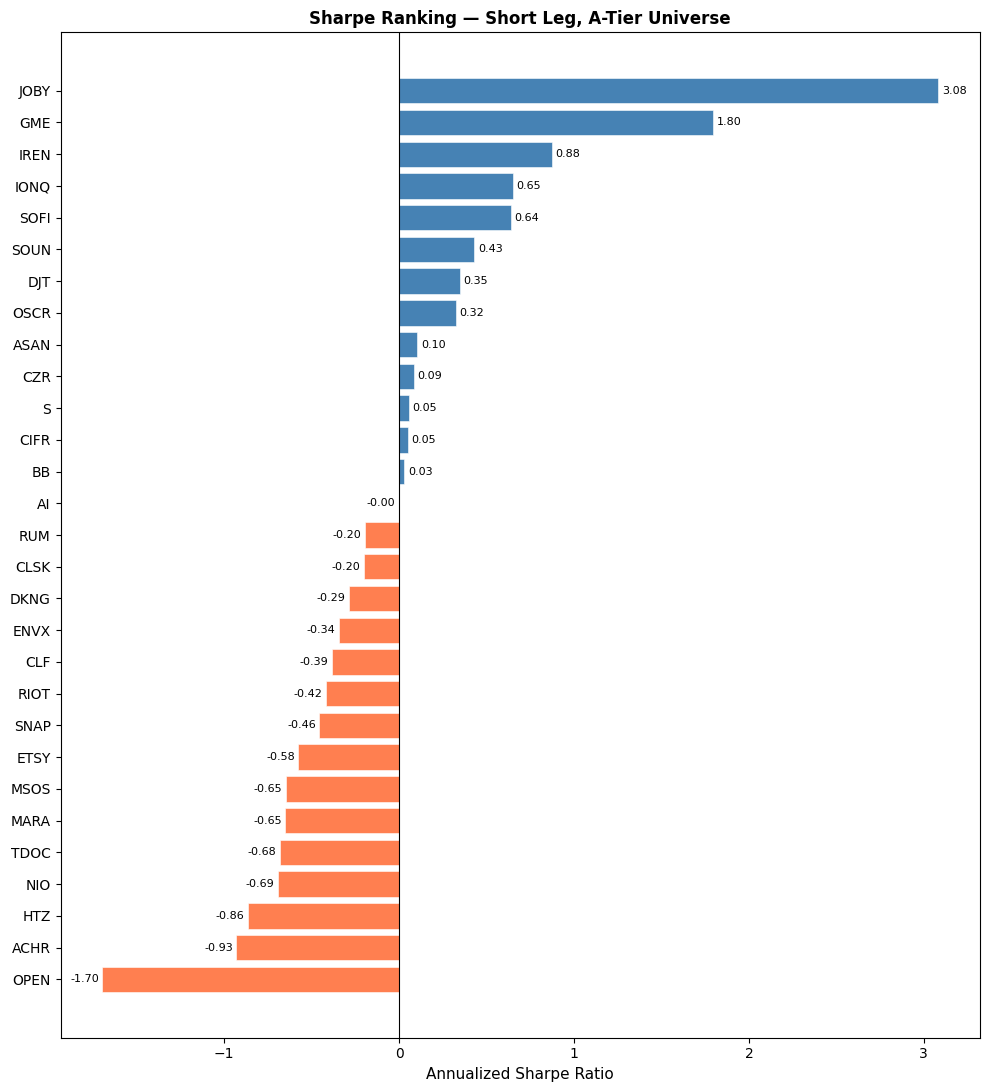

In [17]:
# ── Sharpe ranking bar chart ──────────────────────────────────────────────
if metrics_df.empty:
    print('No metrics to plot.')
else:
    sdf = metrics_df.dropna(subset=['sharpe']).sort_values('sharpe', ascending=True)
    colors = ['coral' if s < 0 else 'steelblue' for s in sdf['sharpe']]

    fig, ax = plt.subplots(figsize=(10, max(6, len(sdf) * 0.38)))
    bars = ax.barh(sdf['ticker'], sdf['sharpe'], color=colors, edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Annualized Sharpe Ratio', fontsize=11)
    ax.set_title('Sharpe Ranking — Short Leg, A-Tier Universe', fontsize=12, fontweight='bold')

    for bar, val in zip(bars, sdf['sharpe']):
        offset = 0.02 if val >= 0 else -0.02
        ha     = 'left' if val >= 0 else 'right'
        ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}', va='center', ha=ha, fontsize=8)

    plt.tight_layout()
    plt.show()

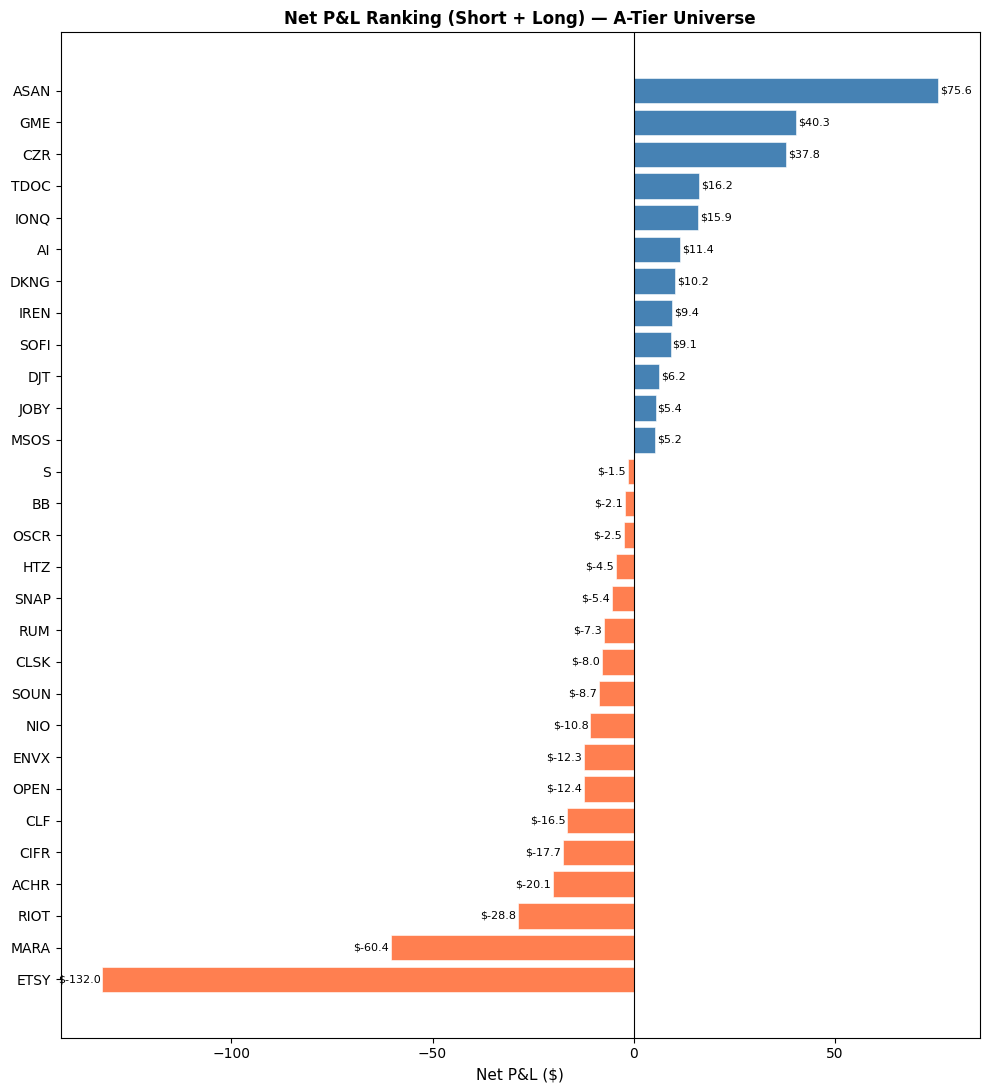

In [18]:
# ── Net P&L ranking bar chart ─────────────────────────────────────────────
if metrics_df.empty:
    print('No metrics to plot.')
else:
    ndf    = metrics_df.sort_values('net_pnl', ascending=True)
    colors = ['coral' if v < 0 else 'steelblue' for v in ndf['net_pnl']]

    fig, ax = plt.subplots(figsize=(10, max(6, len(ndf) * 0.38)))
    bars = ax.barh(ndf['ticker'], ndf['net_pnl'], color=colors,
                   edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Net P&L ($)', fontsize=11)
    ax.set_title('Net P&L Ranking (Short + Long) — A-Tier Universe', fontsize=12, fontweight='bold')

    for bar, val in zip(bars, ndf['net_pnl']):
        offset = 0.5 if val >= 0 else -0.5
        ha     = 'left' if val >= 0 else 'right'
        ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
                f'${val:.1f}', va='center', ha=ha, fontsize=8)

    plt.tight_layout()
    plt.show()

---
## Section 6 — Summary

In [19]:
# ── Printed summary block ─────────────────────────────────────────────────
if metrics_df.empty or all_trades_df.empty:
    print('No data for summary.')
else:
    overall_wr     = float((all_trades_df['pnl'] > 0).mean()) if 'pnl' in all_trades_df.columns else np.nan
    total_short    = float(metrics_df['total_short_pnl'].sum())
    total_long     = float(metrics_df['total_long_pnl'].sum())
    net_all        = float(metrics_df['net_pnl'].sum())
    avg_premium    = float(all_trades_df['bid'].mean()) if 'bid' in all_trades_df.columns else np.nan
    n_windows_all  = len(all_windows_df) if not all_windows_df.empty else 0
    entry_label    = 'Thu+Fri' if ENTRY_DOW is None else ('Thu' if ENTRY_DOW == 3 else 'Fri')

    print('=' * 62)
    print('  KaChing Walk-Forward Backtest  --  Summary')
    print('=' * 62)
    print(f'  Universe         : {TIER_FILTER}-tier | {len(universe)} tickers')
    print(f'  Walk-forward     : train={TRAIN_DAYS}d / test={TEST_DAYS}d / step={STEP_DAYS}d')
    print(f'  Selection method : {SELECTION_METHOD}')
    print(f'  Entry DOW        : {entry_label}')
    print()
    print(f'  Total windows    : {n_windows_all}')
    print(f'  Total trades     : {len(all_trades_df):,}')
    print(f'  Overall win rate : {overall_wr:.1%}')
    print(f'  Avg weekly bid   : ${avg_premium:.3f}')
    print()
    print(f'  Total short P&L  : ${total_short:.2f}')
    print(f'  Total long  P&L  : ${total_long:.2f}')
    print(f'  Net P&L (all)    : ${net_all:.2f}')
    print()
    print('  Top 5 by Sharpe:')
    for _, row in metrics_df.dropna(subset=['sharpe']).head(5).iterrows():
        print(f"    {row['ticker']:<6s}  Sharpe={row['sharpe']:+.2f}  "
              f"WR={row['win_rate']:.1%}  Net=${row['net_pnl']:.1f}")
    print('=' * 62)

  KaChing Walk-Forward Backtest  --  Summary
  Universe         : A-tier | 30 tickers
  Walk-forward     : train=180d / test=120d / step=60d
  Selection method : composite
  Entry DOW        : Thu+Fri

  Total windows    : 687
  Total trades     : 5,493
  Overall win rate : 69.1%
  Avg weekly bid   : $0.671

  Total short P&L  : $-344.30
  Total long  P&L  : $236.26
  Net P&L (all)    : $-108.04

  Top 5 by Sharpe:
    JOBY    Sharpe=+3.08  WR=76.6%  Net=$5.4
    GME     Sharpe=+1.80  WR=77.2%  Net=$40.3
    IREN    Sharpe=+0.88  WR=77.9%  Net=$9.4
    IONQ    Sharpe=+0.65  WR=75.2%  Net=$15.9
    SOFI    Sharpe=+0.64  WR=71.6%  Net=$9.1


In [20]:
# ── Data quality report ───────────────────────────────────────────────────
print('=' * 62)
print('  Data Quality Report')
print('=' * 62)

for ticker in universe:
    res = results.get(ticker)
    if res is None:
        err_msg = errors.get(ticker, 'unknown error')
        print(f'  {ticker:<6s}  FAILED  ({err_msg[:60]})')
        continue

    n_trades  = len(res['trades'])    if not res['trades'].empty    else 0
    n_long    = len(res['long_puts']) if not res['long_puts'].empty else 0
    n_windows = len(res['windows'])   if not res['windows'].empty   else 0

    fallback_str = ''
    if not res['windows'].empty and 'n_trades' in res['windows'].columns:
        total_t = res['windows']['n_trades'].sum()
        total_f = res['windows']['fallback_count'].sum() if 'fallback_count' in res['windows'].columns else 0
        fr = total_f / total_t if total_t > 0 else 0.0
        fallback_str = f'  fallback={fr:.1%}'

    long_warn = '  [!] no long puts' if n_long == 0 else ''

    print(f'  {ticker:<6s}  windows={n_windows:3d}  trades={n_trades:4d}  '
          f'long_puts={n_long:3d}{fallback_str}{long_warn}')

print('=' * 62)

  Data Quality Report
  SNAP    windows= 27  trades= 451  long_puts= 27  fallback=76.7%
  MARA    windows= 27  trades= 431  long_puts= 27  fallback=74.5%
  BB      windows= 26  trades= 143  long_puts= 26  fallback=89.5%
  AI      windows= 27  trades= 294  long_puts= 27  fallback=58.8%
  ENVX    windows= 23  trades= 282  long_puts= 23  fallback=76.2%
  RIOT    windows= 27  trades= 432  long_puts= 27  fallback=78.2%
  NIO     windows= 27  trades= 305  long_puts= 27  fallback=75.7%
  OPEN    windows= 27  trades= 104  long_puts= 27  fallback=90.4%
  TDOC    windows= 27  trades= 451  long_puts= 27  fallback=64.7%
  IONQ    windows= 22  trades= 218  long_puts= 22  fallback=62.4%
  MSOS    windows= 27  trades= 285  long_puts= 27  fallback=81.4%
  DJT     windows=  7  trades= 121  long_puts=  7  fallback=67.8%
  CLSK    windows= 27  trades= 162  long_puts= 27  fallback=80.2%
  SOFI    windows= 24  trades= 345  long_puts= 24  fallback=74.8%
  GME     windows= 17  trades= 293  long_puts= 17  fal